# Sprint 35 — Impact du nombre de features

**Objectif** : étudier 3 conditions de sélection de features × 4 modèles × 5 datasets, sur PC **et**
board NUCLEO-F439ZI. Message central : **l'accuracy est trompeuse en déséquilibre de classes → lire le F1**.

| Condition | features                         | portée                |
|-----------|----------------------------------|-----------------------|
| `5feat`   | 5 (figées firmware)              | référence board       |
| `all`     | toutes natives (ex. CMAPSS=21)   | information maximale   |
| `best`    | top-k par modèle (perm. import.) | optimisé F1 validation |

**Source de vérité** :
- PC    : `experiments/exp_S35_PC_{cond}_{model}_{dataset}/results.json` (60)
- Board : `experiments/exp_S35_board_sweep_summary.json` (60)


In [1]:
import json, sys, glob, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

ROOT = Path.cwd()
if not (ROOT / "experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "experiments").exists()
EXP = ROOT / "experiments"

CONDS = ["5feat", "all", "best"]
MODELS = ["ewc", "hdc", "tinyol", "mahalanobis"]
DATASETS = ["cmapss", "cwru", "monitoring", "paderborn", "pronostia"]
print("ROOT =", ROOT)

ROOT = /home/leonard/Documents/ENAC/cl-embedded


## 1. Chargement PC (60) + board (60)

In [2]:
# PC : un dossier par (condition, model, dataset)
pc_rows = []
for cond in CONDS:
    for m in MODELS:
        for ds in DATASETS:
            f = EXP / f"exp_S35_PC_{cond}_{m}_{ds}" / "results.json"
            if not f.exists():
                pc_rows.append({"condition": cond, "model": m, "dataset": ds, "status": "missing"})
                continue
            r = json.loads(f.read_text())
            pc_rows.append({
                "condition": cond, "model": m, "dataset": ds, "status": "ok",
                "platform": "PC", "n_features": r.get("n_features"),
                "accuracy": r.get("acc_final"), "f1_faulty": r.get("f1_faulty"),
                "f1_macro": r.get("f1_macro"), "ram_peak_bytes": r.get("ram_peak_bytes"),
                "selected_indices": r.get("selected_indices"),
            })
pc = pd.DataFrame(pc_rows)

# Board : sweep summary plat
bd = pd.DataFrame(json.loads((EXP / "exp_S35_board_sweep_summary.json").read_text()))
bd = bd.rename(columns={"online_accuracy": "accuracy", "latency_us_p50": "latency_us"})
bd["platform"] = "board"
print(f"PC valides : {(pc.status=='ok').sum()}/{len(pc)} | Board : {len(bd)}")
pc[pc.status=="ok"].head()

PC valides : 60/60 | Board : 60


,condition,model,dataset,status,platform,n_features,accuracy,f1_faulty,f1_macro,ram_peak_bytes,selected_indices
0,5feat,ewc,cmapss,ok,PC,5,0.914865,0.456028,0.700222,2713161,"[10, 3, 11, 6, 14]"
1,5feat,ewc,cwru,ok,PC,5,1.000000,1.000000,1.000000,59977512,"[3, 4, 6, 7, 8]"
2,5feat,ewc,monitoring,ok,PC,4,0.980437,0.892857,0.941052,251081,"[0, 1, 2, 3]"
3,5feat,ewc,paderborn,ok,PC,5,0.666667,0.800280,0.400140,60000608,"[5, 4, 6, 1, 3]"
4,5feat,ewc,pronostia,ok,PC,5,0.985028,0.930233,0.961249,189249,"[1, 2, 4, 8, 12]"


## 2. Heatmaps F1 (faulty) — modèle × dataset, une grille par condition

On affiche le **F1 de la classe `faulty`** (et non l'accuracy) pour révéler les modèles qui prédisent
la classe majoritaire. PC en haut, board en bas.

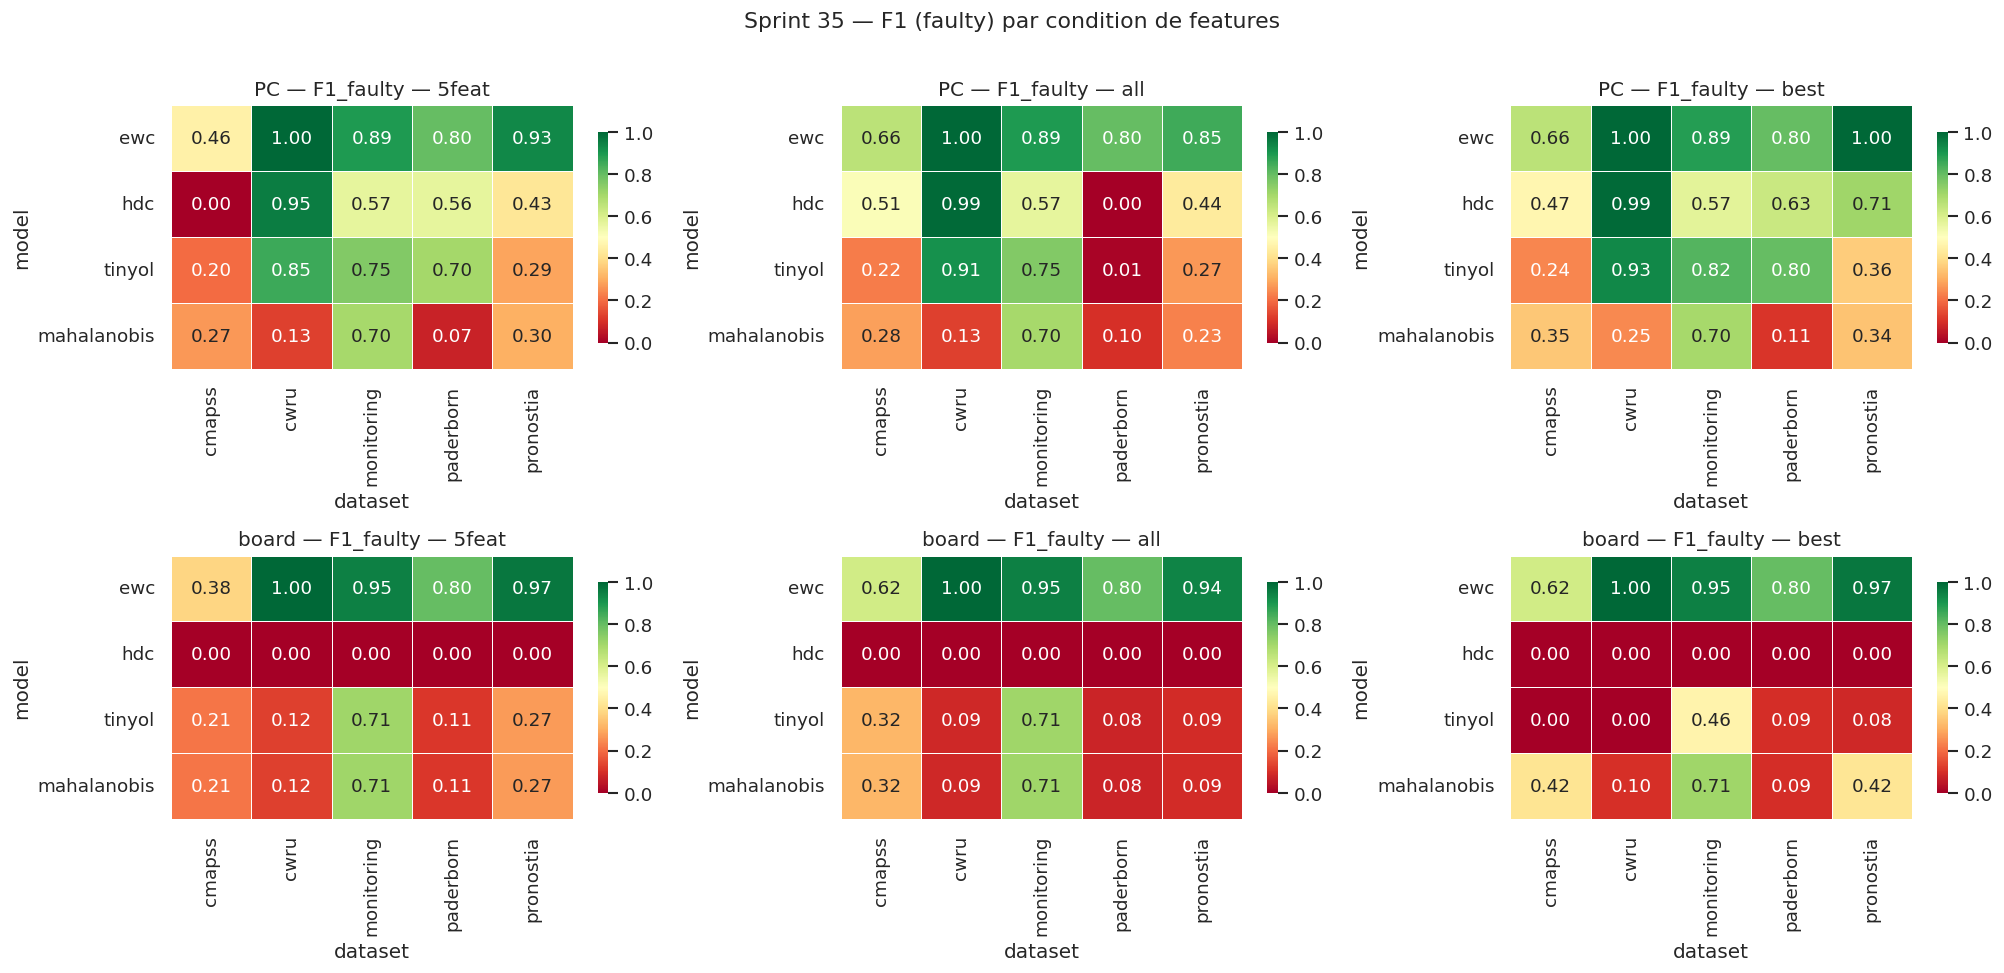

In [3]:
def heat(df, metric, platform, ax, title):
    sub = df[df.get("status", "ok").eq("ok")] if "status" in df else df
    piv = sub.pivot_table(index="model", columns="dataset", values=metric)
    piv = piv.reindex(index=MODELS, columns=DATASETS)
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax,
                linewidths=.5, cbar_kws={"shrink": .8})
    ax.set_title(title)

fig, axes = plt.subplots(2, len(CONDS), figsize=(17, 8))
for j, cond in enumerate(CONDS):
    heat(pc[pc.condition == cond], "f1_faulty", "PC", axes[0, j], f"PC — F1_faulty — {cond}")
    heat(bd[bd.condition == cond], "f1_faulty", "board", axes[1, j], f"board — F1_faulty — {cond}")
fig.suptitle("Sprint 35 — F1 (faulty) par condition de features", y=1.01)
plt.tight_layout(); plt.show()

### 2bis. Accuracy vs F1 — illustration « accuracy trompeuse »

Même grille mais en accuracy : des cellules vertes en accuracy peuvent correspondre à un F1 nul
(HDC board prédit la classe majoritaire → accuracy OK, F1_faulty = 0).

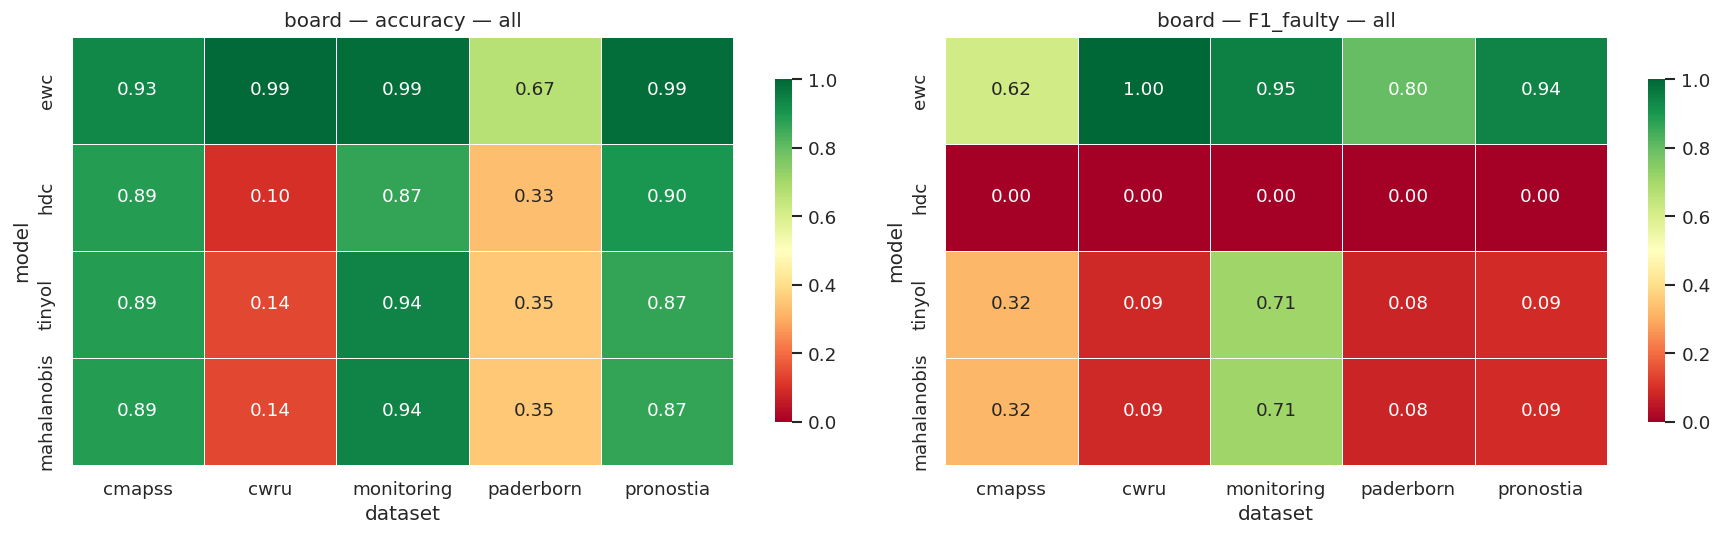

Ex. accuracy trompeuse — board 'all' : cellules à accuracy élevée mais F1_faulty ~0 = prédiction de la classe majoritaire (à lire conjointement).


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
heat(bd[bd.condition == "all"], "accuracy", "board", axes[0], "board — accuracy — all")
heat(bd[bd.condition == "all"], "f1_faulty", "board", axes[1], "board — F1_faulty — all")
plt.tight_layout(); plt.show()
print("Ex. accuracy trompeuse — board 'all' : cellules à accuracy élevée mais F1_faulty ~0 = "
      "prédiction de la classe majoritaire (à lire conjointement).")

## 3. Gain de performance : `best` / `all` vs `5feat`

Δ F1_faulty par rapport à la référence `5feat`, sur PC. Identifie où enrichir les features paie
(typiquement CMAPSS / Pronostia).

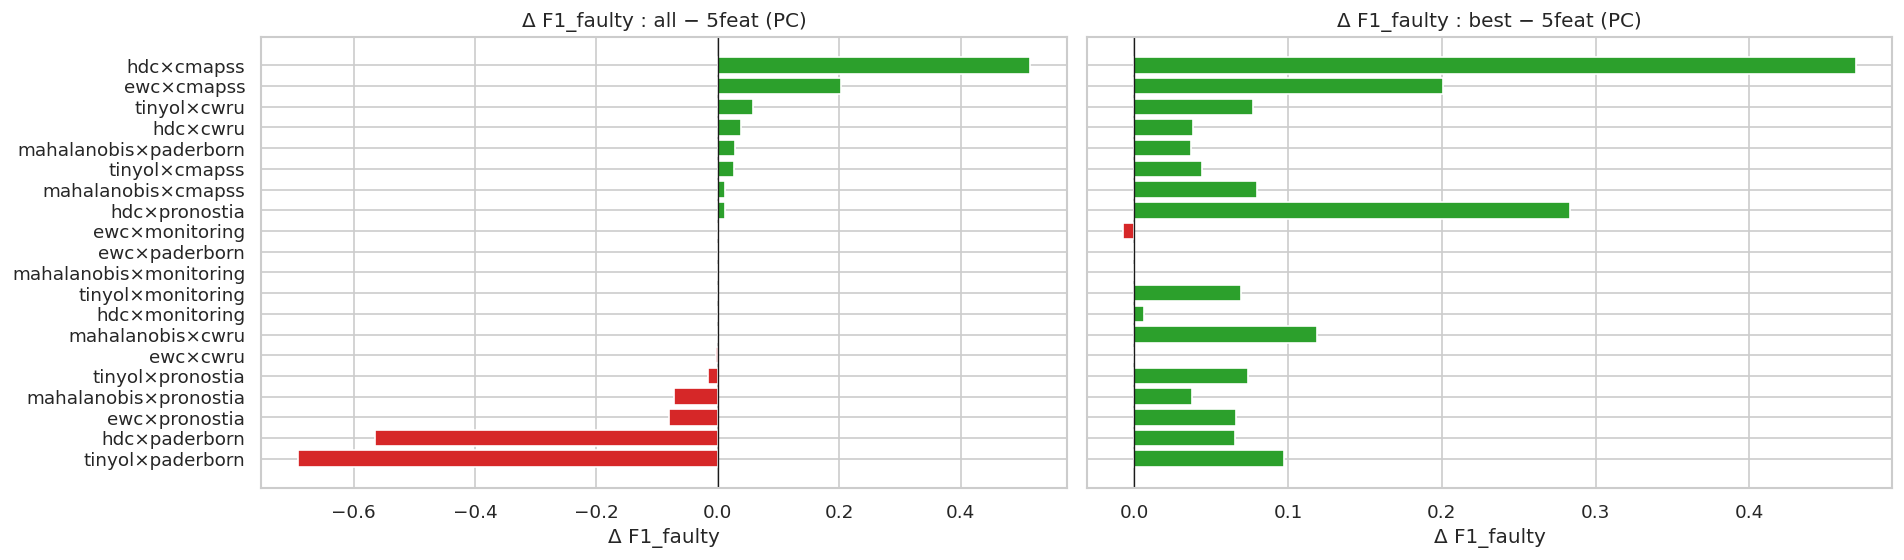

In [5]:
pcok = pc[pc.status == "ok"]
base = pcok[pcok.condition == "5feat"].set_index(["model", "dataset"])["f1_faulty"]
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=True)
for ax, cond in zip(axes, ["all", "best"]):
    cur = pcok[pcok.condition == cond].set_index(["model", "dataset"])["f1_faulty"]
    delta = (cur - base).dropna().reset_index()
    delta["label"] = delta["model"] + "×" + delta["dataset"]
    delta = delta.sort_values("f1_faulty")
    colors = ["#2ca02c" if v >= 0 else "#d62728" for v in delta["f1_faulty"]]
    ax.barh(delta["label"], delta["f1_faulty"], color=colors)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"Δ F1_faulty : {cond} − 5feat (PC)"); ax.set_xlabel("Δ F1_faulty")
plt.tight_layout(); plt.show()

## 4. Coût board : `.bss` et latence vs condition

Enrichir les features augmente la `.bss` (dimensions des têtes) et un peu la latence, mais **Gap 2
(≤ 100 ms) reste préservé** dans toutes les conditions.

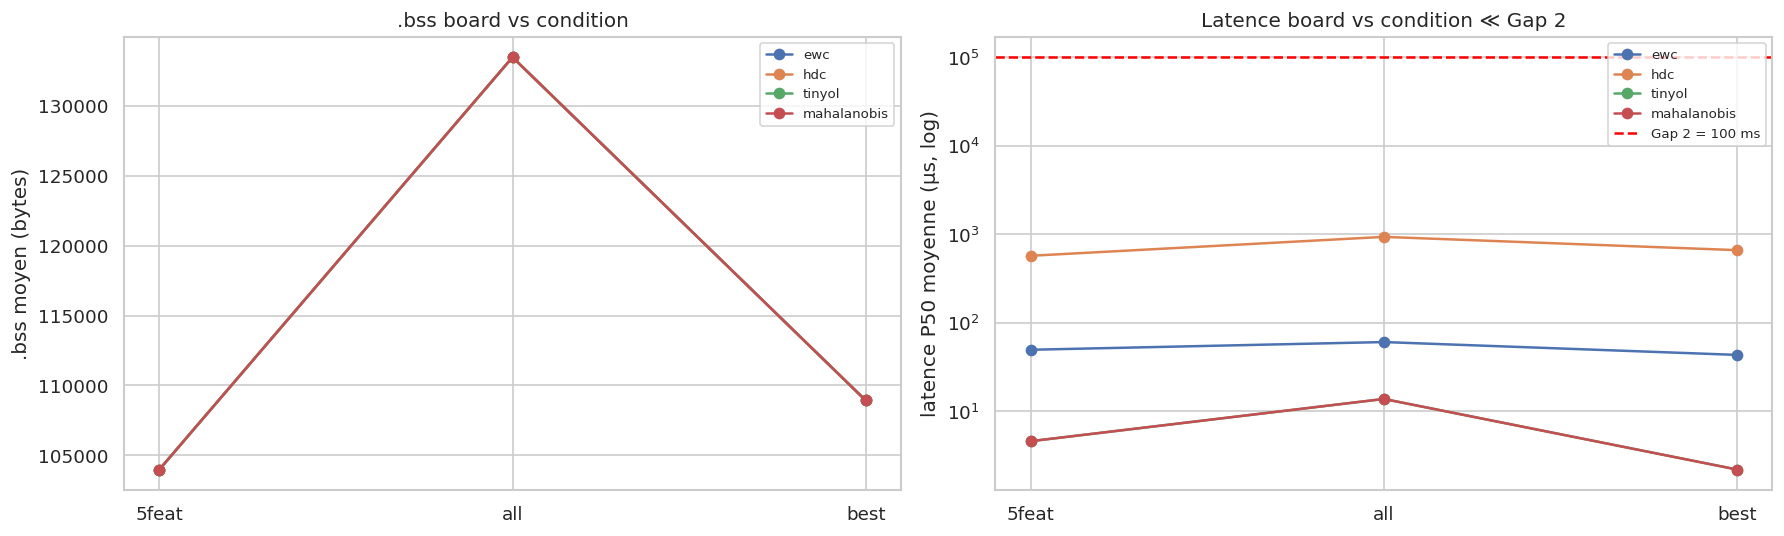

Latence board max (toutes conditions) : 1557.0 µs
.bss board :  85848 → 183936 bytes (70.2 % de 256 Ko)


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))
order = CONDS
for m in MODELS:
    sub = bd[bd.model == m]
    means = [sub[sub.condition == c]["bss_bytes"].mean() for c in order]
    ax1.plot(order, means, "o-", label=m)
ax1.set_ylabel(".bss moyen (bytes)"); ax1.set_title(".bss board vs condition"); ax1.legend(fontsize=8)

for m in MODELS:
    sub = bd[bd.model == m]
    means = [sub[sub.condition == c]["latency_us"].mean() for c in order]
    ax2.plot(order, means, "o-", label=m)
ax2.axhline(100_000, color="red", ls="--", label="Gap 2 = 100 ms")
ax2.set_yscale("log"); ax2.set_ylabel("latence P50 moyenne (µs, log)")
ax2.set_title("Latence board vs condition ≪ Gap 2"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Latence board max (toutes conditions) :", bd["latency_us"].max(), "µs")
print(".bss board : ", bd["bss_bytes"].min(), "→", bd["bss_bytes"].max(), "bytes",
      f"({100*bd['bss_bytes'].max()/(256*1024):.1f} % de 256 Ko)")

## 5. Parité board ↔ PC par modèle

`parity_class` = `exact` (EWC + Mahalanobis, poids exportés, toutes dims k=1→21) ;
HDC / TinyOL = hw_only (parité N/A par construction).

In [7]:
ptab = bd.groupby("model").agg(
    parity_class=("parity_class", lambda s: "/".join(sorted(s.unique()))),
    n=("parity_ok", "size"),
    parity_ok=("parity_ok", lambda s: int(s.fillna(False).sum())),
    mean_rate=("parity_rate", "mean"),
).round(4)
print(ptab)
exact = bd[bd.parity_class == "exact"]
print(f"\nParité exacte : {int(exact['parity_ok'].fillna(False).sum())}/{len(exact)} runs EWC+Maha OK.")

            parity_class   n  parity_ok  mean_rate
model                                             
ewc                exact  15         15        1.0
hdc              hw_only  15          0        NaN
mahalanobis        exact  15         15        1.0
tinyol           hw_only  15          0        NaN

Parité exacte : 30/30 runs EWC+Maha OK.


## 6. Conclusion

- **F1 vs accuracy** : les heatmaps F1_faulty révèlent ce que l'accuracy masque — HDC board prédit
  souvent la classe majoritaire (accuracy correcte, F1_faulty nul). C'est l'argument « accuracy
  trompeuse → lire le F1 ».
- **Enrichissement des features** : `all`/`best` améliorent surtout EWC×CMAPSS et Pronostia ; ailleurs
  le gain est marginal voire négatif (sur-paramétrisation / bruit). Paderborn = class-incremental
  mono-classe/tâche → seul EWC tient.
- **Coût board** : `.bss` croît avec la dimension (jusqu'à ~70 % de 256 Ko en `best cmapss`) et la
  latence reste ≤ ~1.6 ms — **Gap 2 préservé** partout.
- **Parité** EWC + Mahalanobis exacte sur toutes les dimensions ; HDC/TinyOL hw_only.
- **Reco** : 5-feat par défaut ; `best`/`all` ciblé sur CMAPSS + Pronostia.

*Tous les chiffres proviennent des JSON `exp_S35_*` ; aucune valeur saisie à la main.*